###################################################   IMPORTING LIBRARIES   #################################################

In [50]:
#Libraries used
import pandas as pd
import os
import optuna
import joblib
import numpy as np
import xarray as xr
import seaborn as sns
from io import StringIO
from glob import glob
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV, cross_val_score, learning_curve, ParameterGrid
from sklearn.metrics import fbeta_score, make_scorer, precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, r2_score, precision_recall_curve, mean_squared_error, confusion_matrix, recall_score, f1_score, roc_curve, roc_auc_score, make_scorer, precision_score, accuracy_score

###############################################   DATA CLEANING   ############################################

                                                     Data from ANAM

In [ ]:
# 1. Importing the ‘rain_1981_2021’ dataframe/database 
ab=r"D:\MEMORY\Donnees_pluvieux\pluie_1981_2021.csv"
aero=pd.read_csv(ab, sep=",", decimal=".")
aero
# 2. Convert the ‘Date’ column to the datetime data type
aero['Date'] = pd.to_datetime(aero['Date'], format='%Y%m%d').dt.strftime('%d/%m/%y')
aero
# 3. Importing the pluie_2016_2023 dataframe/database and checking the columns
cd=r"D:\MEMORY\Donnees_pluvieux\pluie_2016_2023.csv"
df=pd.read_csv(cd, sep=",", decimal=".")
df
# 4. Rename the columns ‘Year, Month, Day, and ID’ to 'Year, Month, Day, and Precipitation'
df.columns = ['year', 'month','day', 'Precipitation']
df
# 5. Create a true date column, reformat the date as a string, and remove the ‘year’, ‘month’, and ‘day’ columns
df['Date'] = pd.to_datetime(df[['year', 'month', 'day']])
df['Date'] = df['Date'].dt.strftime('%d/%m/%y')
df.drop(columns=['year', 'month', 'day'], inplace=True)
# 6. Reorder the columns
df = df[['Date', 'Precipitation']]
df
# 7. Concatenating the two DataFrames
combined_df = pd.concat([aero, df], ignore_index=True)
combined_df
# 8. Convert the ‘Date’ column to the datetime data type
combined_df['Date'] = pd.to_datetime(combined_df['Date'], format='%d/%m/%y')
# 9. Defining the study date range
start_date = '1991-01-01'
end_date = '2023-12-31'
# 10. Filter the dataframe for this date range
filtered_df = combined_df[(combined_df['Date'] >= start_date) & (combined_df['Date'] <= end_date)]
print(filtered_df)
# 11. Identifying and Displaying Duplicate Rows Based on the ‘Date’ Column
duplicated_rows = filtered_df[filtered_df.duplicated(subset=['Date'], keep=False)]
print("Lignes dupliquées :")
print(duplicated_rows)
print(f"Nombre total de doublons : {duplicated_rows.shape[0]}")
# 12. Save the new dataframe
new = r"D:\MEMORY\Donnees_pluvieux\aero_new.csv"
filtered_df.to_csv(new, index=False)
print(f"Fichier enregistré avec succès à l'emplacement : {new}")

            Date  Precipitations  Precipitation
4018  1991-01-01             0.0            NaN
4019  1991-01-02             0.0            NaN
4020  1991-01-03             0.0            NaN
4021  1991-01-04             0.0            NaN
4022  1991-01-05             0.0            NaN
...          ...             ...            ...
18197 2023-12-27             NaN            0.0
18198 2023-12-28             NaN            0.0
18199 2023-12-29             NaN            0.0
18200 2023-12-30             NaN            0.0
18201 2023-12-31             NaN            0.0

[14184 rows x 3 columns]
Lignes dupliquées :
            Date  Precipitations  Precipitation
13149 2016-01-01             0.0            NaN
13150 2016-01-02             0.0            NaN
13151 2016-01-03             0.0            NaN
13152 2016-01-04             0.0            NaN
13153 2016-01-05             0.0            NaN
...          ...             ...            ...
17406 2021-10-27             NaN          

                                                    DATA FROM WASCAL

In [2]:
################################    Data from BALKUY 2022   ###################################
# 1. Importing the ‘Balkuy_2022’ dataframe or database
ab=r"D:\MEMORY\Donnees_pluvieux\Balkuy_2022.csv"
Bal2=pd.read_csv(ab, sep=";", decimal=",")
# 2. Rename the columns ‘Data, Ora, and Precipitation’ to 'Date, Hour, and Precipitation'
Bal2.columns = ['Date', 'Hour', 'Precipitation']
# 3. Convert the ‘Date’ and ‘Hour’ columns to the datetime data type 
Bal2['Date'] = pd.to_datetime(Bal2['Date'], dayfirst=True).dt.strftime('%d/%m/%y')
Bal2['Hour'] = pd.to_datetime(Bal2['Hour'], format='%H:%M:%S').dt.strftime('%H:%M:%S')
# 4. Identifying missing values and replacing them with 0
Bal2_missing = Bal2.isnull().sum()
Bal2_missing
Bal2.fillna(0, inplace=True)
# 5. Determining missing values after replacement
Bal2_missing = Bal2.isnull().sum()
Bal2_missing
Bal2
bal2=Bal2
# 6. Identifying and removing duplicate rows
db=bal2[bal2.duplicated(subset=['Date' , 'Hour'] , keep=False)]
Balk2 = bal2.drop_duplicates(subset=['Date', 'Hour'] , keep= 'first')
# 7. Verification after removing duplicate rows 
dq=Balk2[Balk2.duplicated(subset=['Date', 'Hour'], keep=False)]
Balk2
# 8. Convert the ‘Date’ column to the datetime data type
Balk2.loc[:,'Date'] = pd.to_datetime(Balk2['Date'], format='%d/%m/%y')
# 9. Daily data summary
daily_Balk2 = Balk2.groupby('Date')['Precipitation'].sum().reset_index()
daily_Balk2
# 10. Save the new dataframe
nouv=r"D:\MEMORY\Donnees_pluvieux\Balkuy_2022_final.csv"
daily_Balk2.to_csv(nouv, index=False)
print("Fichier CSV créé avec succès !")

#######################   Data from BALKUY 2024   ###################################
#1. Importing the ‘Balkuy_2024’ dataframe or database
cd=r"D:\MEMORY\Donnees_pluvieux\Balkuy_2024.csv"
Bal4=pd.read_csv(cd, sep=";", decimal=",")
# 2. Rename the columns ‘Data, Ora, and Precipitation’ to 'Date, Hour, and Precipitation''
Bal4.columns = ['Date', 'Hour', 'Precipitation']
# 3. Convert the ‘Date’ and ‘Hour’ columns to the datetime data type
Bal4['Date'] = pd.to_datetime(Bal4['Date'], dayfirst=True).dt.strftime('%d/%m/%y')
Bal4['Hour'] = pd.to_datetime(Bal4['Hour'], format='%H:%M:%S').dt.strftime('%H:%M:%S')
# 4. Imputation of missing values
Bal4_missing = Bal4.isnull().sum()
Bal4_missing
bal4=Bal4
# 5. Identifying duplicate lines
de=bal4[bal4.duplicated(subset=['Date' , 'Hour'] , keep=False)]
# 6. Convert the ‘Date’ column to the datetime data type
bal4.loc[:, 'Date'] = pd.to_datetime(bal4['Date'], format='%d/%m/%y')
# 7. Daily data summary
daily_bal4 = bal4.groupby('Date')['Precipitation'].sum().reset_index()
daily_bal4
# 8. Save the new dataframe
nouv=r"D:\MEMORY\Donnees_pluvieux\Balkuy_2024_final.csv"
daily_bal4.to_csv(nouv, index=False)
print("Fichier CSV créé avec succès !")

###################################   Data from DASSASGO 2022    #############################
# 1. Importing the ‘Dassasgo_2022’ dataframe or database
cd=r"D:\MEMORY\Donnees_pluvieux\Dassasgo_2022.csv"
Das2=pd.read_csv(cd, sep=";", decimal=",")
Das2
# 2. Rename the columns ‘Data, Ora, and Precipitation’ to 'Date, Hour, and Precipitation'
Das2.columns = ['Date', 'Hour', 'Precipitation']
# 3. Convert the ‘Date’ and ‘Hour’ columns to the datetime data type
Das2['Date'] = pd.to_datetime(Das2['Date'], dayfirst=True).dt.strftime('%d/%m/%y')
Das2['Hour'] = pd.to_datetime(Das2['Hour'], format='%H:%M:%S').dt.strftime('%H:%M:%S')
# 4. Imputation of missing values
Das2_missing = Das2.isnull().sum()
Das2_missing
das2=Das2
# 5. Identifying and removing duplicate rows
ed=das2[das2.duplicated(subset=['Date' , 'Hour'] , keep=False)]
Dass2 = das2.drop_duplicates(subset=['Date', 'Hour'] , keep= 'first')
# 6. Verification after removing duplicate rows 
dq=Dass2[Dass2.duplicated(subset=['Date', 'Hour'], keep=False)]
Dass2
# 7. Convert the ‘Date’ column to the datetime data type
Dass2.loc[:,'Date'] = pd.to_datetime(Dass2['Date'], format='%d/%m/%y')
# 8. Daily data summary
daily_Dass2 = Dass2.groupby('Date')['Precipitation'].sum().reset_index()
daily_Dass2
# 9. Save the new dataframe
nouv=r"D:\MEMORY\Donnees_pluvieux\Dassasgo_2022_final.csv"
daily_Dass2.to_csv(nouv, index=False)
print("Fichier CSV créé avec succès !")

###################################   Data from DASSASGO 2024    #############################
# 1. Importing the ‘Dassasgo_2024’ dataframe or database
cd=r"D:\MEMORY\Donnees_pluvieux\Dassasgo_2024.csv"
Das4=pd.read_csv(cd, sep=";", decimal=",")
Das4
# 2. Rename the columns ‘Data, Ora, and Precipitation’ to 'Date, Hour, and Precipitation'
Das4.columns = ['Date', 'Hour', 'Precipitation']
# 3. Convert the ‘Date’ and ‘Hour’ columns to the datetime data type
Das4['Date'] = pd.to_datetime(Das4['Date'], dayfirst=True).dt.strftime('%d/%m/%y')
Das4['Hour'] = pd.to_datetime(Das4['Hour'], format='%H:%M:%S').dt.strftime('%H:%M:%S')
# 4. Imputation of missing values
Das4_missing = Das4.isnull().sum()
Das4_missing
das4=Das4
# 5. Identifying duplicated lines
ed=das4[das4.duplicated(subset=['Date' , 'Hour'] , keep=False)]
ed
# 6. Convert the ‘Date’ column to the datetime data type
das4.loc[:,'Date'] = pd.to_datetime(das4['Date'], format='%d/%m/%y')
# 7. Daily data summary
daily_das4 = das4.groupby('Date')['Precipitation'].sum().reset_index()
daily_das4
# 8. Save the new dataframe
nouv=r"D:\MEMORY\Donnees_pluvieux\Dassasgo_2024_final.csv"
daily_das4.to_csv(nouv, index=False)
print("Fichier CSV créé avec succès !")

#################################################   Data from KAMBOINSE 2022   ##################################
# 1. Importing the ‘Kamboinse_2022’ dataframe or database
cd=r"D:\MEMORY\Donnees_pluvieux\Kamboinse_2022.csv"
Kam2=pd.read_csv(cd, sep=";", decimal=",")
Kam2
# 2. Rename the columns ‘Data, Ora, and Precipitation’ to 'Date, Hour, and Precipitation'
Kam2.columns = ['Date', 'Hour', 'Precipitation']
# 3. Convert the ‘Date’ and ‘Hour’ columns to the datetime data type
Kam2['Date'] = pd.to_datetime(Kam2['Date'], dayfirst=True).dt.strftime('%d/%m/%y')
Kam2['Hour'] = pd.to_datetime(Kam2['Hour'], format='%H:%M:%S').dt.strftime('%H:%M:%S')
# 4. Identifying missing values and replacing them with 0
Kam2_missing = Kam2.isnull().sum()
Kam2_missing
Kam2.fillna(0, inplace=True)
# 5. Checking for missing values after replacement 
Kam2_missing = Kam2.isnull().sum()
Kam2_missing
kam2=Kam2
# 6. Identifying and removing duplicate rows
ed=kam2[kam2.duplicated(subset=['Date' , 'Hour'] , keep=False)]
ed
Kam2 = kam2.drop_duplicates(subset=['Date', 'Hour'] , keep= 'first')
# 7. Verification after removing duplicate rows
dq=Kam2[Kam2.duplicated(subset=['Date', 'Hour'], keep=False)]
Kam2
# 8. Convert the ‘Date’ column to the datetime data type
Kam2.loc[:,'Date'] = pd.to_datetime(Kam2['Date'], format='%d/%m/%y')
# 9. Sdaily data usage
daily_Kam2 = Kam2.groupby('Date')['Precipitation'].sum().reset_index()
daily_Kam2
# 10. Save the new dataframe
nouv=r"D:\MEMORY\Donnees_pluvieux\Kamboinse_2022_final.csv"
daily_Kam2.to_csv(nouv, index=False)
print("Fichier CSV créé avec succès !")

#################################################   Data from ZONGO 2022   ##################################
# 1. Importing the ‘Zongo_2022’ dataframe or database
cd=r"D:\MEMORY\Donnees_pluvieux\Zongo_2022.csv"
Zon2=pd.read_csv(cd, sep=";", decimal=",")
Zon2
# 2. Rename the columns ‘Data, Ora, and Precipitation’ to 'Date, Hour, and Precipitation'
Zon2.columns = ['Date', 'Hour', 'Precipitation']
# 3. Convert the ‘Date’ and ‘Hour’ columns to the datetime data type
Zon2['Date'] = pd.to_datetime(Zon2['Date'], dayfirst=True).dt.strftime('%d/%m/%y')
Zon2['Hour'] = pd.to_datetime(Zon2['Hour'], format='%H:%M:%S').dt.strftime('%H:%M:%S')
# 4. Imputation of missing values 
Zon2_missing = Zon2.isnull().sum()
Zon2_missing
zon2=Zon2
# 5. Identifying and removing duplicate rows
ed=zon2[zon2.duplicated(subset=['Date' , 'Hour'] , keep=False)]
ed
Zong2 = zon2.drop_duplicates(subset=['Date', 'Hour'] , keep= 'first')
# 6. Verification after removing duplicate rows
dq=Zong2[Zong2.duplicated(subset=['Date', 'Hour'], keep=False)]
Zong2
# 7. Convert the ‘Date’ column to the datetime data type
Zong2.loc[:,'Date'] = pd.to_datetime(Zong2['Date'], format='%d/%m/%y')
# 8. Daily data summary
daily_Zong2 = Zong2.groupby('Date')['Precipitation'].sum().reset_index()
daily_Zong2
# 9. Save the new dataframe
nouv=r"D:\MEMORY\Donnees_pluvieux\Zongo_2022_final.csv"
daily_Zong2.to_csv(nouv, index=False)
print("Fichier CSV créé avec succès !")

######################################################   Data from ZONGO 2024   ############################################
# 1. Importing the ‘Zongo_2024’ dataframe or database
cd=r"D:\MEMORY\Donnees_pluvieux\Zongo_2024.csv"
Zon4=pd.read_csv(cd, sep=";", decimal=",")
Zon4
# 2. Remove columns where all values are NaN
Zon4 = Zon4.dropna(axis=1, how='all')
# 2. Remove rows where all elements are NaN
Zon4 = Zon4.dropna(how='all')
# 3. Convert the ‘Data’ column to the datetime data type to enable comparison
Zon4['Data'] = pd.to_datetime(Zon4['Data'], dayfirst=True).dt.strftime('%d/%m/%y')
# 4. Setting the deadline after which the lines will be deleted
date_limite = '29-10-2024'
# 5. Filter to keep only the rows before the deadline
Zon4 = Zon4[Zon4['Data'] <= date_limite]
# 6. Rename the columns ‘Data, Ora, and Precipitation’ to 'Date, Hour, and Precipitation'
Zon4.columns = ['Date', 'Hour', 'Precipitation']
# 7. Convert the ‘Date’ and ‘Hour’ columns to the datetime data type
Zon4['Hour'] = pd.to_datetime(Zon4['Hour'], format='%H:%M:%S').dt.strftime('%H:%M:%S')
# 8. Imputation of missing values
Zon4_missing = Zon4.isnull().sum()
Zon4_missing
zon4=Zon4
# 9. Identifying duplicate lines
ed=zon4[zon4.duplicated(subset=['Date' , 'Hour'] , keep=False)]
ed
# 10. Convert the ‘Date’ column to the datetime data type
zon4.loc[:,'Date'] = pd.to_datetime(zon4['Date'], format='%d/%m/%y')
# 11. Daily data summary
daily_zon4 = zon4.groupby('Date')['Precipitation'].sum().reset_index()
daily_zon4
# 12. Save the new dataframe
nouv=r"D:\MEMORY\Donnees_pluvieux\Zongo_2024_final.csv"
daily_zon4.to_csv(nouv, index=False)
print("Fichier CSV créé avec succès !")

################################################    Data from BOASSA 2017 à 2024  ###############################################
# 1. IImporting the ‘Boassa_2017_2024’ dataframe or database
cd=r"D:\MEMORY\Donnees_pluvieux\Bouassa_2017_2024.csv"
Boa=pd.read_csv(cd, sep=",", decimal=".")
# 2. Selecting columns by index
Boa=Boa.iloc[:, [0, 16]]
# 3. Convert the ‘date’ column to the datetime data type and into a DataFrame
Boa['date'] = pd.to_datetime(Boa['date'], errors='coerce')
Boa=pd.DataFrame(Boa)
# 4. Extracting the date and time from the ‘Date’ column
Boa['Date'] = Boa['date'].dt.date 
Boa['Hour'] = Boa['date'].dt.strftime('%H:%M:%S')  
# 5. Replace missing values in the ‘rainfall_10’ column with 0
Boa['rainfall_10'] = Boa['rainfall_10'].fillna(0)
# 6. Selecting columns by index
Boa=Boa.iloc[:, [1, 2, 3]]
# 7. Rename the ‘rainfall_10’ column to 'Precipitation'
Boa.rename(columns={'rainfall_10': 'Precipitation'}, inplace=True)
# 8. Reordering the columns in the dataframe
Boa = Boa[['Date', 'Hour', 'Precipitation']]
# 9. Determining missing values after replacing them with 0
Boa_missing = Boa.isnull().sum()
Boa_missing
Boa
boa=Boa
boa
# 10. Convert the ‘Date’ column to the datetime data type
boa['Date'] = pd.to_datetime(boa['Date'], format='%Y-%m-%d')
# 11. Defining the date range for filtering
start_date = pd.to_datetime('2020-01-01')
end_date = pd.to_datetime('2024-12-31')
# 12. Filter the dataframe for this date range
Boas = boa[(boa['Date'] >= start_date) & (boa['Date'] <= end_date)]
print(Boas)
# 13. Identifying duplicate lines
ed=Boas[Boas.duplicated(subset=['Date' , 'Hour'] , keep=False)]
ed
# 14. Daily data summary
daily_Boas = Boas.groupby('Date')['Precipitation'].sum().reset_index()
daily_Boas
# 15. Save the new dataframe
nouv=r"D:\MEMORY\Donnees_pluvieux\Boassa_2020_2024_final.csv"
daily_Boas.to_csv(nouv, index=False)
print("Fichier CSV créé avec succès !")

Fichier CSV créé avec succès !
Fichier CSV créé avec succès !
Fichier CSV créé avec succès !
Fichier CSV créé avec succès !
Fichier CSV créé avec succès !
Fichier CSV créé avec succès !
Fichier CSV créé avec succès !
             Date      Hour  Precipitation
118224 2020-01-01  00:00:00            0.0
118225 2020-01-01  00:10:00            0.0
118226 2020-01-01  00:20:00            0.0
118227 2020-01-01  00:30:00            0.0
118228 2020-01-01  00:40:00            0.0
...           ...       ...            ...
361003 2024-08-12  23:10:00            0.0
361004 2024-08-12  23:20:00            0.0
361005 2024-08-12  23:30:00            0.0
361006 2024-08-12  23:40:00            0.0
361007 2024-08-12  23:50:00            0.0

[242784 rows x 3 columns]
Fichier CSV créé avec succès !


                                                      FLOOD DATA

In [ ]:
################################################  Flood events from 1991 to 2022  ###########################################
# 1. Importing the ‘inondation_1991_2019’ dataframe or database
dj=r"D:\MEMORY\Donnees_pluvieux\inondation_1991_2019.csv"
Inond=pd.read_csv(dj, sep=";")
# 2. Creating the base DataFrame with dates ranging from January 1, 1991, to December 31, 2023
date_range = pd.date_range(start='1991-01-01', end='2023-12-31', freq='D')
df = pd.DataFrame(date_range, columns=['date'])
df['date'] = pd.to_datetime(df['date'])
df['Evenement'] = 0
# 3. Adding empty columns for flood information to the base dataframe
df['day'] = None
df['year'] = None
df['month'] = None
df['Ville'] = None
df['Arrondissement'] = None
df['Secteur'] = None
df['Nombre Secteur'] = None
# 4. Integration of flood data from the ‘inondation_1991_2019’ database
for _, row in Inond.iterrows():
    event_date = pd.to_datetime(row['date'], errors='coerce', dayfirst=True)
    if pd.notna(event_date):
        df.loc[df['date'] == event_date, 'Evenement'] = 1
        df.loc[df['date'] == event_date, 'day'] = row['day']
        df.loc[df['date'] == event_date, 'year'] = row['year']
        df.loc[df['date'] == event_date, 'month'] = row['month']
        df.loc[df['date'] == event_date, 'Ville'] = row['Ville']
        df.loc[df['date'] == event_date, 'Arrondissement'] = row['Arrondissement']
        df.loc[df['date'] == event_date, 'Secteur'] = row['Secteur']
        df.loc[df['date'] == event_date, 'Nombre Secteur'] = row['Nombre Secteur']

# 5. Final cleanup and display of results
df = df[['date', 'Secteur' , 'Evenement']]
df['Secteur'] = df['Secteur'].str.replace('secteur ', '') 
df['Secteur'] = df['Secteur'].str.strip() 
df = df.rename(columns={"date": "Date"})
print(df.head())
# 6. Save the new CSV file
new=r"D:\MEMORY\Donnees_pluvieux\inondation_1991_new.csv"
df.to_csv(new, index=False, sep=";")
print("Fichier csv créé avec succès ! ")

###########################################################  Flood events from 2022 to 2023  ################################################
# 1. Importing the dataframe or database 'inondation22_par_sect'
ab=r"D:\MEMORY\Donnees_pluvieux\inondation22_par_sect.csv"
inond=pd.read_csv(ab, sep=";")
inond.head()
df=pd.DataFrame(inond)
# 2. Convert the ‘Date’ column to the datetime data type
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y %H:%M")
# 3. Create a dataframe (calendar) covering the period from January 1, 2022, to December 31, 2023
date_range = pd.date_range(start="2022-01-01", end="2023-12-31", freq="D").date
df_calendar = pd.DataFrame({"Date": date_range})
# 4. List of days with events
df_calendar["Evenement"] = df_calendar["Date"].apply(lambda date: 1 if date in df["Date"].dt.date.values else 0)
# 5. Grouping of sectors by date
def group_sectors(Date):
    matching_rows = df[df["Date"].dt.date == Date]
    if not matching_rows.empty:
        return ", ".join(matching_rows["SECTEUR"].unique())
    return None
# Convert dates to datetime objects for easier processing
df_calendar["Date"] = pd.to_datetime(df_calendar["Date"], format="%d/%m/%Y %H:%M")
# Applying the function to calendar dates
df_calendar["Secteur"] = df_calendar["Date"].dt.date.apply(group_sectors)
# 6. Cleaning up sector names and reorganizing columns
df_calendar['Secteur'] = df_calendar['Secteur'].str.replace('SECTEUR ', '') 
df_calendar['Secteur'] = df_calendar['Secteur'].str.strip()  
columns = [col for col in df_calendar.columns if col != 'Evenement']  
columns.append('Evenement')  
df_calendar = df_calendar[columns]  
df_calendar
# 7. Save the new CSV file
new=r"D:\MEMORY\Donnees_pluvieux\inondation_2022_new.csv"
df_calendar.to_csv(new, index=False, sep=";")
print("Fichier csv créé avec succès ! ")

################################################################  Merging the two dataframes  ######################################################
# 1. Importing the ‘inondation_1991_new’ and ‘inondation_2022_new’ databases
ab=r"D:\MEMORY\Donnees_pluvieux\inondation_1991_new.csv"
ind=pd.read_csv(ab, sep=";")
ind.head()
cd=r"D:\MEMORY\Donnees_pluvieux\inondation_2022_new.csv"
dat=pd.read_csv(cd, sep=";")
dat.head()
# 2. Converting ‘Date’ columns to the datetime data type
ind["Date"] = pd.to_datetime(ind["Date"])
dat["Date"] = pd.to_datetime(dat["Date"])
# 3. Creating a dataframe containing dates ranging from January 1, 1991, to December 31, 2023
dates = pd.date_range(start='1991-01-01', end='2023-12-31', freq='D')
dates_df = pd.DataFrame({'Date': dates})
# 4. Merge the “dat” and ‘ind’ DataFrames based on the “Date” column
merged_df = pd.merge(dates_df, dat, on='Date', how='left')
merged_df = pd.merge(merged_df, ind, on='Date', how='left', suffixes=('_dat', '_ind'))
# 5. Fill in missing events with 0 if necessary
merged_df['Evenement_dat'] = merged_df['Evenement_dat'].fillna(0).astype(int)
merged_df['Evenement_ind'] = merged_df['Evenement_ind'].fillna(0).astype(int)
# 6. Merge columns into a single column if necessary
merged_df['Secteur_dat'] = merged_df['Secteur_dat'].fillna('')
merged_df['Secteur_ind'] = merged_df['Secteur_ind'].fillna('')
merged_df['Secteur'] = merged_df['Secteur_dat'] + ',' + merged_df['Secteur_ind']
merged_df['Secteur'] = merged_df['Secteur'].apply(lambda x: x.strip(','))
final_df = merged_df[['Date', 'Secteur', 'Evenement_dat', 'Evenement_ind']]
final_df = final_df.copy()
final_df.loc[:, 'Evenement'] = final_df['Evenement_dat'] + final_df['Evenement_ind']
# 7. Selecting the final columns 
final_df = final_df[["Date", "Secteur", "Evenement"]]
final_df
# 8. Save the new dataframe 
new=r"D:\MEMORY\Donnees_pluvieux\inondation_new.csv"
final_df.to_csv(new, index=False, sep=";")
print("Fichier csv créé avec succès ! ")

#################################################       DATA ANALYSIS   ####################################

                                                    RELATIONSHIP BETWEEN ANAM DATA AND FLOOD EVENTS

In [ ]:
# 1. Importing the ‘aero_new’ and ‘inondation_new’ databases
ab=r"D:\MEMORY\Donnees_pluvieux\aero_new.csv"
pluvio=pd.read_csv(ab, sep=",", decimal=".")
cd=r"D:\MEMORY\Donnees_pluvieux\inondation_new.csv"
inond=pd.read_csv(cd, sep=";")
inond.head()
# 2. Creating DataFrames
inond = pd.DataFrame(inond)
pluvio = pd.DataFrame(pluvio)
# 3. Convert the ‘Date’ columns to the datetime data type
inond['Date'] = pd.to_datetime(inond['Date'], format="%Y-%m-%d")
pluvio['Date'] = pd.to_datetime(pluvio['Date'], format='%Y-%m-%d')
# 4. Merge the two DataFrames based on the ‘Date’ column
merged = pd.merge(inond, pluvio, on='Date', how='left')
merged = merged[['Date', 'Precipitation', 'Secteur' , 'Evenement']]
merged
# 5. Filter rows where Event equals 1
merged_1=merged[merged['Evenement']==1]
merged_1
# 6. Save the new dataframe
nouv=r"D:\MEMORY\Donnees_pluvieux\relation_aero_inond1.csv"
merged_1.to_csv(nouv, index=False, sep=";")
print("Fichier CSV créé avec succès !")
# 7. Filter rows where Event is equal to 0
merged
merged_0=merged[merged['Evenement']==0]
merged_0
# 8. Saving the second CSV file titled 'No Flooding'
nouv=r"D:\MEMORY\Donnees_pluvieux\relation_aero_inond0.csv"
merged_0.to_csv(nouv, index=False, sep=";")
print("Fichier CSV créé avec succès !")


                                                    CHIRPS RAINFALL DATA

In [ ]:
# 1. Importing the ‘chirps_dataset_1991_2024’ database
chirps_dir = r"D:\MEMORY\Chirps\chirps_dataset_1991_2024"
# 2. List of all NetCDF files in the folder
chirps_files = sorted(glob(os.path.join(chirps_dir, "*.nc")))
print(f"Nombre de fichiers trouvés : {len(chirps_files)}")
# 3. Automatic merging of NetCDF files by aligning coordinates
combined_data = xr.open_mfdataset(
    chirps_files,
    combine="by_coords",   
    combine_attrs="override"  
)
# 4. Importing the ‘Centroid1_secteurs_ouaga’ database
centroid_file = r"D:\MEMORY\Chirps\chirps_dataset_1991_2024\Centroid1_secteurs_Ouaga.csv"  
centroids = pd.read_csv(centroid_file, sep=";", decimal=",")
centroids.head()
# 5. Checking column names for coordinates
lon_col, lat_col = "X", "Y" 
chirps_lon_col, chirps_lat_col = "longitude", "latitude"  
# 6. Data extraction for each centroid
results = []
for _, row in centroids.iterrows():
    lon, lat = row[lon_col], row[lat_col]
    
    # Extracting data for the given coordinates
    extracted_data = combined_data.sel(
        {chirps_lon_col: lon, chirps_lat_col: lat}, method="nearest"
    ).to_dataframe().reset_index()
    
    # Add an identifier for each centroid 
    extracted_data["centroid_id"] = row.get("id", None)
    results.append(extracted_data)

# 7. Combined results
final_data = pd.concat(results, ignore_index=True)
final_data
# 8. Save the new dataframe
nouv=r"D:\MEMORY\Chirps\chirps_dataset_1991_2024\Donnees_Chirps1.csv"
final_data.to_csv(nouv, index=False, sep=";")
print("Fichier CSV créé avec succès !")


In [ ]:
# 1. Importing the ‘Donnees_Chirps1’ database
ab=r"D:\MEMORY\Chirps\chirps_dataset_1991_2024\Donnees_Chirps1.csv"
chr=pd.read_csv(ab, sep=";", decimal=".")
chr.head()
# 2. Data transformation: precipitation by centroid_id
result = chr.pivot(index="time", columns="centroid_id", values="precip")
# 3. Renaming columns for clarity
result.columns = [f"centroid_{int(col)}" for col in result.columns]
print(result)
chp = pd.DataFrame(result)
# 4. Add the “sect_” prefix only to numeric columns (or strings representing numbers)
chp.rename(
    columns=lambda col: f"sect_{col}" if col.isdigit() else col,
    inplace=True
)

chp.head()
# 5. Save the new dataframe
nouv=r"D:\MEMORY\Donnees_pluvieux\chirps1_secteur.csv"
chp.to_csv(nouv, index=True, sep=";")
print("Fichier CSV créé avec succès !")

                                                RELATIONSHIP BETWEEN ANAM DATA, FLOOD EVENTS, AND CHIRPS

In [ ]:
# 1. Importing the ‘Donnees_Chirps1’ database
ab=r"D:\MEMORY\Chirps\chirps_dataset_1991_2024\Donnees_Chirps1.csv"
chr=pd.read_csv(ab, sep=";", decimal=".")
chr.head()
# 2. Filter and display rows where centroid_id == 47 
chirp = chr[chr["centroid_id"] == 47]
print(chirp)
# 3. Importing the ‘relation_aero_inond’ database
cd=r"D:\MEMORY\Donnees_pluvieux\relation_aero_inond.csv"
aer=pd.read_csv(cd, sep=";")
aer.head()
# 4. Creating data frames
chp=pd.DataFrame(chirp)
aer=pd.DataFrame(aer)
# 5. Converting ‘Date and Time’ columns to the datetime data type
aer["Date"] = pd.to_datetime(aer["Date"])
chp["time"] = pd.to_datetime(chp["time"])
# 6. Merge the `precip` and `time` columns into `aer` based on dates
aer = aer.merge(chp[["time", "precip"]], left_on="Date", right_on="time", how="left")
# 7. Removing the `time` column and renaming the columns for clarity
aer = aer.drop(columns=["time"])
aer = aer.rename(columns={"precip": "Precipitation_chirps"})
aer = aer.rename(columns={"Precipitation": "Precipitation_anam"})
aer = aer[['Date', 'Precipitation_anam', 'Precipitation_chirps', 'Secteur' , 'Evenement']]
aer
# 8. Save the new dataframe
nouv=r"D:\MEMORY\Donnees_pluvieux\relation_aero_chirps1.csv"
aer.to_csv(nouv, index=False, sep=";")
print("Fichier CSV créé avec succès !")

######################################################            VIEWING GRAPHS          #####################################

                                                                 PDF  -  CDF

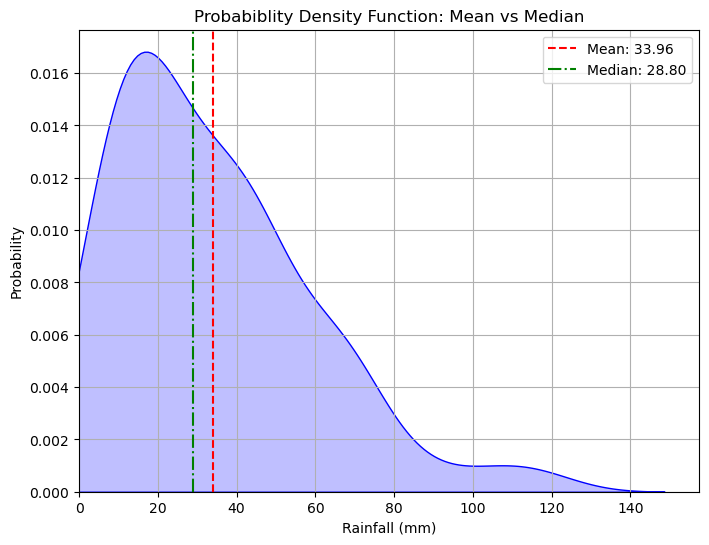

Cadrant 1:
  Précipitation minimale: 4.10 mm
  Précipitation maximale: 25.40 mm

Cadrant 2:
  Précipitation minimale: 30.60 mm
  Précipitation maximale: 105.20 mm

Cadrant 3:
  Précipitation minimale: 4.80 mm
  Précipitation maximale: 27.20 mm

Cadrant 4:
  Précipitation minimale: 28.80 mm
  Précipitation maximale: 116.70 mm

Nombre d'événements dans chaque cadrant :
Cadrant 1: 16 événements
Cadrant 2: 17 événements
Cadrant 3: 18 événements
Cadrant 4: 18 événements


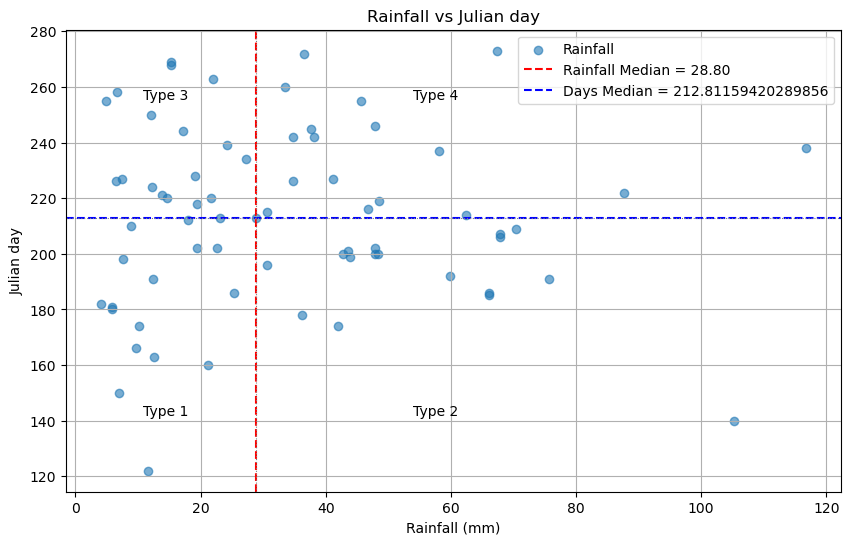

Index(['Date', 'Julian day', 'Precipitation_anam', 'Precipitation_chirps',
       'Secteur', 'Evenement', 'Type'],
      dtype='object')


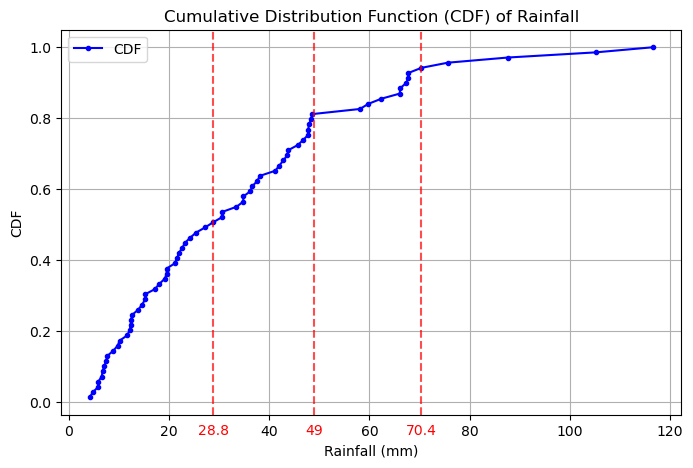

Precipitation_anam
<=28.8     35
28.8-49    21
49-70.4     9
>70.4       4
Name: count, dtype: int64
Secteurs présents dans le Cadrant 4 :
  10 : 09/08/2016
  15, 38 : 14/08/2022
  17 : 26/08/2007
  17, 18 : 03/09/2013
  2 : 01/09/2012, 29/09/2018
  29 : 04/08/2022
  29, 42, 51, 52, 15, 43 : 03/08/2022
  4 : 15/08/2013, 30/09/2013
  43, 51 : 07/08/2023
  51 : 01/08/2023, 12/09/2022, 30/08/2022
  52 : 17/09/2023
  7, 28 : 02/08/2013
  8, 10, 11, 12, 13, 17, 19, 20, 23 : 25/08/2002
  9, 51 : 30/08/2023

Secteurs présents dans le Cadrant 4 :
  10 : 09/08/2016
  15, 38 : 14/08/2022
  17 : 26/08/2007
  17, 18 : 03/09/2013
  2 : 01/09/2012, 29/09/2018
  29 : 04/08/2022
  29, 42, 51, 52, 15, 43 : 03/08/2022
  4 : 15/08/2013, 30/09/2013
  43, 51 : 07/08/2023
  51 : 01/08/2023, 12/09/2022, 30/08/2022
  52 : 17/09/2023
  7, 28 : 02/08/2013
  8, 10, 11, 12, 13, 17, 19, 20, 23 : 25/08/2002
  9, 51 : 30/08/2023

Secteurs présents dans le Cadrant 4 :
  10 : 09/08/2016
  15, 38 : 14/08/2022
  17 : 26

In [ ]:
# Importing the "relation_aero_chirps1_vo" database
ab=r"D:\MEMORY\Donnees_pluvieux\relation_aero_chirps1_vo.csv"
chp=pd.read_csv(ab, sep=";", decimal=".")
# Filter the rows where Event == 1
chp = chp[chp["Evenement"] == 1]
chp=pd.DataFrame(chp)
# Creation of the figure
plt.figure(figsize=(8, 6))
# KDE curve with probability on the y-axis
sns.kdeplot(chp["Precipitation_anam"], color="blue", fill=True, common_norm=False)
# Adding the mean and median to the graph
mean_value = chp["Precipitation_anam"].mean()
median_value = chp["Precipitation_anam"].median()
plt.axvline(mean_value, color="red", linestyle="--", label=f"Mean: {mean_value:.2f}")
plt.axvline(median_value, color="green", linestyle="-.", label=f"Median: {median_value:.2f}")
# Customizing the chart
plt.xlabel("Rainfall (mm)")
plt.ylabel("Probability")
plt.title("Probabiblity Density Function: Mean vs Median")
plt.legend()
plt.grid(True)
# Limit the values on the x-axis to a minimum of zero
plt.xlim(left=0)
plt.show()
# Rename the column
chp.rename(columns={"Jour_julien": "Julian day"}, inplace=True)

# Select the precipitation data to use (here, we'll use “Precipitation_anam”)
Rainfall = chp["Precipitation_anam"]

# Calculate the median precipitation and the average number of Julian days
median_precip = Rainfall.median()
mean_jour = chp["Julian day"].mean()

# Create a new column to determine which quadrant each row is in
chp["Type"] = 0
chp.loc[(chp["Precipitation_anam"] < median_precip) & (chp["Julian day"] < mean_jour), "Type"] = 1
chp.loc[(chp["Precipitation_anam"] >= median_precip) & (chp["Julian day"] < mean_jour), "Type"] = 2
chp.loc[(chp["Precipitation_anam"] < median_precip) & (chp["Julian day"] >= mean_jour), "Type"] = 3
chp.loc[(chp["Precipitation_anam"] >= median_precip) & (chp["Julian day"] >= mean_jour), "Type"] = 4

# Count the number of events in each quadrant
event_counts = chp["Type"].value_counts().sort_index()

# Display the minimum and maximum precipitation for each quadrant
for cadrant in range(1, 5):
    events_in_cadrant = chp[chp["Type"] == cadrant]

    # Retrieve the minimum and maximum precipitation values
    min_precip = events_in_cadrant["Precipitation_anam"].min()
    max_precip = events_in_cadrant["Precipitation_anam"].max()

    print(f"Cadrant {cadrant}:")
    print(f"  Précipitation minimale: {min_precip:.2f} mm")
    print(f"  Précipitation maximale: {max_precip:.2f} mm")
    print()

# Display the results in the console
print("Nombre d'événements dans chaque cadrant :")
for cadrant, count in event_counts.items():
    print(f"Cadrant {cadrant}: {count} événements")

# Create the chart
plt.figure(figsize=(10, 6))

# Scatter plot
plt.scatter(Rainfall, chp["Julian day"], label="Rainfall", alpha=0.6)

# Center lines
plt.axvline(x=median_precip, color='red', linestyle='--',
            label=f'Rainfall Median = {median_precip:.2f}')
plt.axhline(y=mean_jour, color='blue', linestyle='--',
            label=f'Days Median = {mean_jour}')

# Headings
plt.title("Rainfall vs Julian day")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Julian day")
plt.legend(loc='upper right')

# Dial markings
plt.axvline(x=median_precip, color='gray', linestyle=':', linewidth=0.8)
plt.axhline(y=mean_jour, color='gray', linestyle=':', linewidth=0.8)

# Dial labels
plt.text(median_precip / 2, mean_jour / 1.5, "Type 1", ha='center')
plt.text(median_precip * 2, mean_jour / 1.5, "Type 2", ha='center')
plt.text(median_precip / 2, mean_jour * 1.2, "Type 3", ha='center')
plt.text(median_precip * 2, mean_jour * 1.2, "Type 4", ha='center')

# Display
plt.grid(True)
plt.show()

print(chp.columns)
# Select the precipitation column and remove the missing values
precip_data = chp["Precipitation_anam"]

# Sort precipitation values
sorted_precip = np.sort(precip_data)

# Calculate the empirical CDF
cdf = np.arange(1, len(sorted_precip) + 1) / len(sorted_precip)

# Plot the CDF
plt.figure(figsize=(8, 5))
plt.plot(sorted_precip, cdf, marker='.', linestyle='-', color='b', label='CDF')

# Add vertical lines at the values 28.8, 50, and 70.4
values = [28.8, 49, 70.4]
for val in values:
    plt.axvline(x=val, color='red', linestyle='--', alpha=0.7)
    # Place the text below the x-axis
    plt.text(val, -0.06, f'{val}', rotation=0, va='top', ha='center', color='red')

# Customizing labels and graphics
plt.xlabel("Rainfall (mm)")
plt.ylabel("CDF")
plt.title("Cumulative Distribution Function (CDF) of Rainfall")
plt.grid(True)

# View the graph
plt.legend()
plt.show()
# Set the intervals
chi=[0, 28.8, 49, 70.4, np.inf]
int=["<=28.8", "28.8-49", "49-70.4", ">70.4"]

# Analyzing precipitation in the classroom
cat=pd.cut(precip_data, bins=chi, labels=int, right=True)

# Count the number of events in each interval
count=cat.value_counts().sort_index()
print(count)
# Identify the sectors and dates in each quadrant
secteurs_par_cadrant = {}

for type in range(1, 5):
    # Select events from the dial
    events_in_cadrant = chp[chp["Type"] == type]

    # Group by sector and retrieve the associated dates
    secteurs_dates = events_in_cadrant.groupby("Secteur")["Date"].apply(list).to_dict()

    # Sort the sectors in alphabetical order
    secteurs_par_cadrant[type] = {secteur: sorted(dates) for secteur, dates in sorted(secteurs_dates.items())}

# Display the sectors and dates for each quadrant
for cadrant in range(1, 5):
    print(f"Secteurs présents dans le Cadrant {type} :")
    
    if secteurs_par_cadrant[type]:  
        for secteur, dates in secteurs_par_cadrant[type].items():
            dates_str = ", ".join(dates) 
            print(f"  {secteur} : {dates_str}")
    else:
        print("  Aucun secteur dans ce cadrant.")

    print()  
# List for storing data in a table format
data_for_csv = []

# Fill in the list with information on the shifts, sectors, and dates
for type in range(1, 5):
    for secteur, dates in secteurs_par_cadrant[type].items():
        data_for_csv.append([type, secteur, ", ".join(dates)])  

# Create a DataFrame from the list
df_csv = pd.DataFrame(data_for_csv, columns=["Type", "Secteur", "Dates"])


#####################################################  DATA ANALYSIS      #######################################################

                                                        RELATIONSHIP BETWEEN PRECIPITATION, FLOOD EVENTS, AND PRECURSORS

In [ ]:
# 1. Importing the ‘relation_aero_chirps1_vo’ database
ab=r"D:\MEMORY\Donnees_pluvieux\relation_aero_chirps1_vo.csv"
aero=pd.read_csv(ab, sep=";")
aero.head()
df=pd.DataFrame(aero)
# 2. Create an empty list for new rows
new_data = []
# Iterate through the rows of the DataFrame
for _, row in df.iterrows():
    if row['Evenement'] == 1 and pd.notna(row['Secteur']):
        Secteurs = row['Secteur'].split(',')  
        for sec in Secteurs:
            sec = sec.strip()
            new_data.append({
                'Date': row['Date'],
                'Jour_julien': row['Jour_julien'],
                'Precipitation_anam': row['Precipitation_anam'],
                'Precipitation_chirps': row['Precipitation_chirps'],
                'Secteur': sec,
                'Evenement':row['Evenement']
            })
    else:
        new_data.append({
            'Date': row['Date'],
            'Jour_julien': row['Jour_julien'],
            'Precipitation_anam': row['Precipitation_anam'],
            'Precipitation_chirps': row['Precipitation_chirps'],
            'Secteur': row['Secteur'], 
            'Evenement':row['Evenement']
        })
# 3. Creating a new DataFrame
df_new = pd.DataFrame(new_data)
# 4. Importing the ‘Tableau_precurseurs’ database
cd=r"D:\MEMORY\Donnees_pluvieux\Tableau_precurseurs.csv"
pre=pd.read_csv(cd, sep=";", decimal=",")
pre.head()
df_new
# 5. Creating DataFrames and converting the ‘sector’ column to int64 to facilitate merging
sect = pd.DataFrame(df_new)
pre = pd.DataFrame(pre)
sect["Secteur"] = sect["Secteur"].astype("Int64")
pre["Secteur"] = pre["Secteur"].astype("Int64")
# 6. Merge the two DataFrames based on the ‘Sector’ column
df_final = sect.merge(pre, on="Secteur", how="left")
print(df_final)
# 7. Save the new dataframe
new=r"D:\MEMORY\Donnees_pluvieux\precurseurs.csv"
df_final.to_csv(new, index=False, sep=";")
print("Fichier csv créé avec succès ! ")

             Date  Jour_julien  Precipitation_anam  Precipitation_chirps  \
0      01/01/1991            1                 0.0                   0.0   
1      02/01/1991            2                 0.0                   0.0   
2      03/01/1991            3                 0.0                   0.0   
3      04/01/1991            4                 0.0                   0.0   
4      05/01/1991            5                 0.0                   0.0   
...           ...          ...                 ...                   ...   
12152  27/12/2023          361                 0.0                   0.0   
12153  28/12/2023          362                 0.0                   0.0   
12154  29/12/2023          363                 0.0                   0.0   
12155  30/12/2023          364                 0.0                   0.0   
12156  31/12/2023          365                 0.0                   0.0   

       Secteur  Evenement  valeur_Minimale  Nb_inondation  \
0         <NA>          0 

                                                        DUPLICATION OF SECTORS THROUGHOUT THE DATABASE

In [42]:
# 1. Importing the ‘precursors’ database
ab=r"D:\MEMORY\Donnees_pluvieux\precurseurs.csv"
df=pd.read_csv(ab, sep=";")
df.head()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
# 2. Creating a function to duplicate rows and assign sectors
def completer_secteurs(df):
    all_sectors = set(range(1, 56))  
    new_rows = []  
    original_order = df['Date'].unique()  

    dates_a_completer = df[df['Evenement'] == 1]['Date'].unique()
    
    for date in dates_a_completer:
        secteurs_existants = set(df[df['Date'] == date]['Secteur'].dropna().astype(int).tolist())
        secteurs_manquants = sorted(all_sectors - secteurs_existants)
        ref_row = df[df['Date'] == date].iloc[0].copy()

        for secteur in secteurs_manquants:
            new_row = ref_row.copy()
            new_row['Secteur'] = secteur
            new_row['Evenement'] = 0
            new_rows.append(new_row)

    df_complet = pd.concat([df, pd.DataFrame(new_rows)], ignore_index=True)
    
    df_complet = df_complet.dropna(subset=['Secteur'])
    df_complet['Secteur'] = df_complet['Secteur'].astype(int)

    df_complet.sort_values(by=['Date', 'Secteur'], inplace=True)
    df_complet.reset_index(drop=True, inplace=True)
    
    return df_complet

# 3. Applying the function to the DataFrame df
df_complet = completer_secteurs(df)
print(df_complet)
# 4. “Use the data from 07/28/2010” to propagate throughout the entire database
def propager_valeurs_reference(df, date_reference='28/07/2010'):
    ref_values = df[df['Date'] == date_reference][['Secteur', 'Superficie_depotoir', 'Longueur_caniveau', 'Plan_eau', 'Type_sol']]
    df = df.drop(columns=['Superficie_depotoir', 'Longueur_caniveau', 'Plan_eau', 'Type_sol'])  
    df = df.merge(ref_values, on='Secteur', how='left')  

    return df

# 5. Applying the function to the DataFrame `df_complete`
df_complet = propager_valeurs_reference(df_complet)
print(df_complet)
#6. Importing the ‘chirps1_sector’ database
cd=r"D:\MEMORY\Donnees_pluvieux\chirps1_secteur.csv"
chr=pd.read_csv(cd, sep=";")
chr.head()
chr['Date'] = pd.to_datetime(chr['Date'], dayfirst=True)
# 7. Merge ‘df_complet’ and ‘chr’ based on the date
df_complet = df_complet.merge(chr, on="Date", how="left")
df_complet
# 8. Creating a new column to store the modified precipitation data
df_complet["Precipitation_nouvelle"] = df_complet["Precipitation_anam"]
# 9. Apply the change only where Event == 0 and Sector ≠ 4
mask = (df_complet["Evenement"] == 0) & (df_complet["Secteur"] != 4)
# 10. Rainfall update for affected areas only
df_complet.loc[mask, "Precipitation_nouvelle"] = df_complet.loc[mask].apply(
    lambda row: row[f"sect_{int(row['Secteur'])}"] if f"sect_{int(row['Secteur'])}" in chr.columns else row["Precipitation_nouvelle"],
    axis=1
)
# 11. Removal of temporary columns in sectors added by chr
secteur_cols = [col for col in df_complet.columns if col.startswith("sect_")]
df_complet.drop(columns=secteur_cols, inplace=True)
ordre=["Date", "Precipitation_anam", "Precipitation_nouvelle", "Secteur", "Evenement", "Superficie_depotoir", "Longueur_caniveau", "Plan_eau", "Type_sol"]
df_complet=df_complet[ordre]
print(df_complet.head())
# 12. Filter the data to keep only the entries from May through September of each year
mask = (df_complet['Date'].dt.month >= 5) & (df_complet['Date'].dt.month <= 9)
dfi = df_complet.loc[mask].copy()
# 13. Save the new dataframe
nouv=r"D:\MEMORY\Donnees_pluvieux\Modele.csv"
dfi.to_csv(nouv, index=False, sep=";")
print("Fichier csv créé avec succès ! ")


           Date  Jour_julien  Precipitation_anam  Precipitation_chirps  \
0    1991-05-20          140           105.20000              6.249236   
1    1991-05-20          140           105.20000              6.249236   
2    1991-05-20          140           105.20000              6.249236   
3    1991-05-20          140           105.20000              6.249236   
4    1991-05-20          140           105.20000              6.249236   
...         ...          ...                 ...                   ...   
3790 2023-09-17          260            33.44731             33.503570   
3791 2023-09-17          260            33.44731             33.503570   
3792 2023-09-17          260            33.44731             33.503570   
3793 2023-09-17          260            33.44731             33.503570   
3794 2023-09-17          260            33.44731             33.503570   

      Secteur  Evenement  valeur_Minimale  Nb_inondation  Superficie_depotoir  \
0           1          1      

                                                        REGPRESSION OF THE HUMIDITY VARIABLE

In [ ]:
# 1. Importing the ‘Modele’ database
ab=r"D:\MEMORY\Donnees_pluvieux\Modele.csv"
df=pd.read_csv(ab, sep=";")
df.head()
# 3. Importing the ‘Relief’ database
ij=r"D:\MEMORY\Donnees_precurseur\Relief.csv"
reli=pd.read_csv(ij, sep=";", decimal=",")
reli.head()
# 4. Convert the ‘Date’ column to the datetime data type
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True) 
# 5. Merger between ‘df’ and 'reli'
merged = pd.merge(df, reli, on="Secteur", how="left")
merged.head()
# 6. Importing the ‘Temperature’ database
cd=r"D:\MEMORY\Donnees_precurseur\Temperature.csv"
temp=pd.read_csv(cd, sep=";")
temp.head()
# 7. Create a ‘Date’ column for 'temp'
temp['Date'] = pd.to_datetime(temp[['year', 'month', 'day']])
# 8. Merge ‘dfi’ and ‘temp’ on the ‘Date’ column
merged1 = pd.merge(merged, temp[['Date', 'temp_moyenne']], on='Date', how='left')
merged1
# 9. Importing the ‘Humidite_sol’ database and converting humi to long format
kl=r"D:\MEMORY\Donnees_precurseur\Humidite_sol.csv"
humi=pd.read_csv(kl, sep=";")
humi_long = humi.melt(id_vars=["sect"], var_name="Date", value_name="Humidite")
# 10. Convert the ‘Date’ column to the datetime data type and rename the ‘Sector’ column 
humi_long["Date"] = pd.to_datetime(humi_long["Date"], format="%Y%m%d")
humi_long.rename(columns={"sect": "Secteur"}, inplace=True)
humi_long.head()
# 11. Merger of ‘merged1’ and 'humi_long'
merged2 = pd.merge(merged1, humi_long, on=["Secteur", "Date"], how="left")
merged2
# 12. Check for missing values and convert the ‘Date’ column to the datetime data type
print(merged2.isnull().sum())
merged2["Date"] = pd.to_datetime(merged2["Date"], dayfirst=True, errors="coerce")
# 13. Filter by time period using humidity values (2015–2023)
df_2015_2023 = merged2[merged2["Date"].dt.year >= 2015]

#############################################   Regression   ###########################################################

# 15. Merge and remove missing values to keep only complete rows
df_filtered = df_2015_2023[["temp_moyenne", "Precipitation", "Humidite"]].dropna()

# 16. Redefining X and Y after removing missing values
X = df_filtered[["temp_moyenne", "Precipitation"]]
y = df_filtered["Humidite"]
# 17. Verifying the size after correction
print(f"Taille corrigée de X : {X.shape}")
print(f"Taille corrigée de y : {y.shape}")
# 18. Linear model, prediction, and R² score
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2_linear = r2_score(y, y_pred)
print(f"R² du modèle linéaire : {r2_linear:}")
# 19. Creating a polynomial model (degree 2)
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
# 20. Training, prediction, and R² score
poly_model.fit(X, y)
y_poly_pred = poly_model.predict(X) 
r2_poly = r2_score(y, y_poly_pred)
print(f"R² du modèle polynomial : {r2_poly:}")
# 21. Filtering the original dataset for the period from 1991 to 2023
df_1991_2023 = merged2[(merged2["Date"] >= "1991-05-01") & (merged2["Date"] <= "2023-09-30")]
# 22. Filtering data from May through September
df_missing = df_1991_2023[(df_1991_2023["Date"].dt.month >= 5) & (df_1991_2023["Date"].dt.month <= 9)]
# 23. Prediction using the polynomial model
df_missing["Humidite_predite"] = poly_model.predict(df_missing[["temp_moyenne", "Precipitation"]])
# 24. Replace NaN values in ‘Humidity’ with predictions 
df_1991_2023["Humidite"] = df_1991_2023["Humidite"].fillna(df_missing["Humidite_predite"])
df_1991_2023.head()
# 25. Data split based on humidity values (non-missing)
df_with_humidity = df_1991_2023[df_1991_2023["Humidite"].notnull()]
# 26. Prediction of humidity values
X_with_humidity = df_with_humidity[["temp_moyenne", "Precipitation"]]
y_with_humidity = df_with_humidity["Humidite"]
y_pred = poly_model.predict(X_with_humidity)
# 27. Calculation of RMSE and R²
rmse = np.sqrt(mean_squared_error(y_with_humidity, y_pred))
print(f"RMSE : {rmse}")
r2 = r2_score(y_with_humidity, y_pred)
print(f"R² : {r2}")
# 28. Save the new CSV file 'Modele_final1'
nouv=r"D:\MEMORY\Donnees_pluvieux\Modele_final1.csv"
df_1991_2023.to_csv(nouv, index=False, sep=";")
print("Fichier csv créé avec succès ! ")

Date                        0
Precipitation               0
Secteur                     0
Evenement                   0
Superficie_depotoir         0
Longueur_caniveau           0
Plan_eau                    0
Type_sol                    0
Relief                      0
temp_moyenne                0
Humidite               251515
dtype: int64
Taille corrigée de X : (26180, 2)
Taille corrigée de y : (26180,)
R² du modèle linéaire : 0.5961789117461596
R² du modèle polynomial : 0.6032409601927761
RMSE : 0.016587913326540627
R² : 0.9505589209241877
Fichier csv créé avec succès ! 


#####################################                    MODELING                 ########################################################

                                                        MODEL DEVELOPMENT: Machine Learning

In [ ]:
ab=r"D:\MEMORY\Donnees_pluvieux\Modele_final1.csv"
df=pd.read_csv(ab, sep=";")
df.head()
# 1. Data preparation
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Annee'], df['Mois'], df['Jour'] = df['Date'].dt.year, df['Date'].dt.month, df['Date'].dt.day
df.drop('Date', axis=1, inplace=True)
X = df.drop('Evenement', axis=1)
y = df['Evenement']

# 2. Data split: Training / Validation 85% / 15%
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.15,                 
    random_state=42
)

print(f"Taille train : {X_train.shape[0]} échantillons ({X_train.shape[0]/len(df)*100:.1f} %)")
print(f"Taille val   : {X_val.shape[0]} échantillons ({X_val.shape[0]/len(df)*100:.1f} %)")

# Display the breakdown for review
print("Répartition y_train :", y_train.value_counts(normalize=True))
print("Répartition y_val   :", y_val.value_counts(normalize=True))

n_pos = y_train.sum()
n_train = len(y_train)
print(f"{n_pos} positifs sur {n_train} échantillons ({n_pos/n_train*100:.4f} %)")

n_pos_val = y_val.sum()
n_val     = len(y_val)
print(f"{n_pos_val} positifs sur {n_val} échantillons ({n_pos_val/n_val*100:.3f} %)")

# 3. CV and SMOTE Configurations
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
configs = [
    {'name': 'SMOTE only',        'lr_weight': None,       'xgb_weight': None},
    {'name': 'SMOTE + weighting', 'lr_weight': 'balanced', 'xgb_weight': pos_weight}
]
smote_rates = [0.05, 0.10, 0.20, 0.30]

# 4. Basic grids and classifiers
param_grids = {
    'RandomForest': {'clf__n_estimators': [100], 'clf__max_depth': [5,10,None]},
    'XGBoost': {
        'clf__n_estimators': [50,100], 'clf__max_depth': [3,5,7],
        'clf__learning_rate': np.linspace(0.01,0.2,5), 'clf__subsample': [0.7,1.0]
    },
    'LightGBM': {
        'clf__n_estimators': [50,100], 'clf__max_depth': [-1,5,10],
        'clf__learning_rate': np.linspace(0.01,0.2,5), 'clf__subsample': [0.7,1.0],
        'clf__verbosity': [-1]
    },
    'LogisticRegression': None,
    'KNN': {'clf__n_neighbors': [3,5,7]}
}

base_clfs = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost':      XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM':     LGBMClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(solver='liblinear', random_state=42),
    'KNN':                KNeighborsClassifier()
}

# 5. Nested CV
results = []
best_settings = {}
best_pipelines = {}
for name, base_clf in base_clfs.items():
    best_f2 = -1
    for cfg in configs:
        for rate in smote_rates:
            steps = []
            if name in ['LogisticRegression','KNN']:
                steps.append(('scaler', StandardScaler()))
            steps.append(('smote', SMOTE(sampling_strategy=rate, random_state=42)))
            steps.append(('clf', base_clf.__class__(**base_clf.get_params())))
            pipe = Pipeline(steps)
            # Choose GridSearchCV if the number of combinations is ≤ 10; otherwise, choose RandomizedSearchCV
            param_space = list(ParameterGrid(param_grids[name] or {}))
            if len(param_space) <= 10:
                search = GridSearchCV(
                    pipe,
                    param_grids[name] or {},
                    scoring=f2_scorer, cv=inner_cv,
                    n_jobs=2, verbose=1
                )
            else:
                search = RandomizedSearchCV(
                    pipe,
                    param_distributions=param_grids[name] or {},
                    n_iter=10,
                    scoring=f2_scorer, cv=inner_cv,
                    n_jobs=2, random_state=42, verbose=1
                )
            # Internal fit and determination of the best parameters
            search.fit(X_train, y_train)
            inner_best = search.best_params_
            # External evaluation
            scores = cross_val_score(
                search, X_train, y_train,
                scoring=f2_scorer, cv=outer_cv, n_jobs=2
            )
            mean_f2 = scores.mean()
            # Add the results for all tested combinations
            results.append({
                'model': name,
                'config': cfg['name'],
                'smote_rate': rate,
                'f2_mean': mean_f2,
                'best_params': inner_best
            })
            if mean_f2 > best_f2:
                best_f2 = mean_f2
                best_settings[name] = {'config': cfg['name'], 'smote_rate': rate, 'best_params': inner_best}
                best_pipelines[name] = search.best_estimator_
            
# 6. Selection of the best configurations
results_df     = pd.DataFrame(results)
best_per_model = results_df.sort_values('f2_mean', ascending=False).drop_duplicates('model')
print("=== Meilleure config par modèle ===")
display(best_per_model)

# 7. Dictionaries for storing results
val_preds_proba = {}
test_preds_proba = {}
seuils_val = {}
f2_scores_val = {}
f1_scores_val = {}
precisions_val = {}
recalls_val = {}
accuracies_val = {}
errors_val = {}
cms_val = {}

f2_scores_test = {}
f1_scores_test = {}
precisions_test = {}
recalls_test = {}
accuracies_test = {}
errors_test = {}
cms_test = {}

pipelines_best = {}

# 8. Training + finding the optimal threshold upon validation
for _, row in best_per_model.iterrows():
    name = row['model']
    smote_rate = row['smote_rate']
    best_params = row['best_params']
    
    # Set up the pipeline
    steps = []
    if name in ['LogisticRegression', 'KNN']:
        steps.append(('scaler', StandardScaler()))
    steps.append(('smote', SMOTE(sampling_strategy=smote_rate, random_state=42)))

    # Clear parameters to remove 'clf__'
    model_params = {k.replace('clf__',''): v for k, v in best_params.items() if k.startswith('clf__')}
    clf = base_clfs[name].__class__(**model_params)
    steps.append(('clf', clf))
    
    pipe = Pipeline(steps)
    pipe.fit(X_train, y_train)
    pipelines_best[name] = pipe
    
    # Probability predictions based on validation
    y_val_proba = pipe.predict_proba(X_val)[:, 1]
    val_preds_proba[name] = y_val_proba
    
    # Find the optimal threshold to maximize F2 on the validation set
    seuils = np.linspace(0, 1, 101)
    f2s = [fbeta_score(y_val, (y_val_proba >= s).astype(int), beta=2) for s in seuils]
    best_idx = np.argmax(f2s)
    seuil_opt = seuils[best_idx]
    seuils_val[name] = seuil_opt
    
    # Binary prediction with an optimal threshold on the validation set
    y_val_pred = (y_val_proba >= seuil_opt).astype(int)
    
    # Calculate metrics upon validation
    f2_scores_val[name] = f2s[best_idx]
    f1_scores_val[name] = f1_score(y_val, y_val_pred)
    precisions_val[name] = precision_score(y_val, y_val_pred)
    recalls_val[name] = recall_score(y_val, y_val_pred)
    accuracies_val[name] = accuracy_score(y_val, y_val_pred)
    errors_val[name] = 1 - accuracies_val[name]
    cms_val[name] = confusion_matrix(y_val, y_val_pred)

# 9. Validation fusion (average of probabilities)
val_fused_proba = np.mean(np.column_stack(list(val_preds_proba.values())), axis=1)
# 10. Search for the optimal threshold for data validation
f2s_fused_val = [fbeta_score(y_val, (val_fused_proba >= s).astype(int), beta=2) for s in seuils]
best_idx_fused_val = np.argmax(f2s_fused_val)
seuil_fused_val = seuils[best_idx_fused_val]
seuils_val['Fusion'] = seuil_fused_val

val_fused_pred = (val_fused_proba >= seuil_fused_val).astype(int)

f2_scores_val['Fusion'] = f2s_fused_val[best_idx_fused_val]
f1_scores_val['Fusion'] = f1_score(y_val, val_fused_pred)
precisions_val['Fusion'] = precision_score(y_val, val_fused_pred)
recalls_val['Fusion'] = recall_score(y_val, val_fused_pred)
accuracies_val['Fusion'] = accuracy_score(y_val, val_fused_pred)
errors_val['Fusion'] = 1 - accuracies_val['Fusion']
cms_val['Fusion'] = confusion_matrix(y_val, val_fused_pred)

niveau_confiance_val = np.mean([f2_scores_val[m] for m in best_per_model['model']])

# 11. Validation table display
df_val = pd.DataFrame({
    'Modèle': list(f2_scores_val.keys()),
    'Seuil': [seuils_val[m] for m in f2_scores_val.keys()],
    'F2-score': [f2_scores_val[m] for m in f2_scores_val.keys()],
    'F1-score': [f1_scores_val[m] for m in f1_scores_val.keys()],
    'Précision': [precisions_val[m] for m in precisions_val.keys()],
    'Rappel': [recalls_val[m] for m in recalls_val.keys()],
    'Accuracy': [accuracies_val[m] for m in accuracies_val.keys()],
    'Erreur': [errors_val[m] for m in errors_val.keys()]
})

print("=== Évaluation sur Validation ===")
display(df_val)
print(f"Niveau de confiance (moyenne F2 modèles seuls) : {niveau_confiance_val:.4f}")

# 12. Save the model
import joblib
model_bundle = {
    'pipelines': pipelines_best,        
    'seuils': seuils_val,               
    'niveau_confiance': niveau_confiance_val,
    'feature_names': list(X_train.columns)
}
joblib.dump(model_bundle, "model_inondation.pkl")

Taille train : 236040 échantillons (85.0 %)
Taille val   : 41655 échantillons (15.0 %)
Répartition y_train : Evenement
0    0.999174
1    0.000826
Name: proportion, dtype: float64
Répartition y_val   : Evenement
0    0.999208
1    0.000792
Name: proportion, dtype: float64
195 positifs sur 236040 échantillons (0.0826 %)
33 positifs sur 41655 échantillons (0.079 %)
